# Collimated Comparison

In [1]:
%pip install diffinytrace.zip

Processing .\diffinytrace.zip
Note: you may need to restart the kernel to use updated packages.


ERROR: Could not install packages due to an OSError: [Errno 2] No such file or directory: 'C:\\Users\\marti\\Documents\\GitHub\\diffinytrace\\examples\\diffinytrace.zip'



In [2]:
from google.colab import drive
drive.mount('/content/gdrive')
from os import listdir
from os.path import isfile, join
path = "gdrive/MyDrive/results_final"


ModuleNotFoundError: No module named 'google'

In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath(".."))
path = "results/results_fincal_collimated_compare"

In [2]:
import sys
import os
import gc
import tqdm
device = "cuda:0"

In [ ]:
import diffinytrace as dit
import torch
import numpy as np
torch.set_default_dtype(torch.float64)
import random

SEED = 0
np.random.seed(SEED)
torch.manual_seed(SEED)
random.seed(SEED)


from diffinytrace.source import CollimatedMonochromatic,CollimatedGaussianBeam
from diffinytrace.gaussian_smoother import GaussianSmootherSquare,make_merit_function,make_evaluation_function
import matplotlib.pyplot as plt

def run_optimiaztion(sigma,use_desired_irradiance_smoothing,return_system=False):
    in_aperture = 4.0
    in_aperture_lens = 5.0

    desired_width_square = 4.0

    out_aperture = 8.0
    source_wl = 0.589
    source_gaussian_constant = 0.035

    light_transform = dit.transforms.Identity()
    source = CollimatedGaussianBeam(light_transform,in_aperture,source_wl,source_gaussian_constant)

    lens_mat = dit.materials["BAK1"]#dit.materials["NBK7"]
    env_mat = dit.materials["AIR"]

    lens1_thickness = 2.
    lens1_surf1 = dit.Bspline(in_aperture_lens,[4,4],[11,11])#dit.Legendre(in_aperture_lens,20)#
    lens1_surf2 = dit.Plane()

    det_surf = dit.Plane()

    lens1_transform = dit.transforms.Distance(5.0,parent_transform=source)
    lens1_transform.distance.requires_grad = False

    lens1 = dit.Lens(lens1_transform,lens1_thickness,lens1_surf1,lens1_surf2,lens_mat,in_aperture_lens,is_square=False)


    det_transform = dit.transforms.Distance(10.,parent_transform=lens1)
    det_transform.distance.requires_grad = False
    detector = dit.Detector(det_transform,det_surf,out_aperture)

    system = dit.SequentialOpticalSystem({"source":source,"lens1":lens1,"detector":detector},env_mat)
    system.to(device)
    sequence = ["source","lens1","detector"]

    N = 2**17
    grid_size = 128

    def desired_irradiance_fun(y):
        out = (torch.abs(y[:,0]) < desired_width_square).float() * (torch.abs(y[:,1]) < desired_width_square).float()
        return out

    smoother = GaussianSmootherSquare(out_aperture,
                                    grid_size=grid_size,
                                    sigma=sigma,
                                    desired_irradiance_fun=desired_irradiance_fun,
                                    smoothed_num_integration_points=2**22,
                                    smoothed_num_splits=10,
                                    device=device)
    #dit.plotting.quantity2D.plot(smoother.smoothed_desired_irradiance,"Smoothed [W/mm²]",out_aperture)
    #dit.plotting.quantity2D.plot(smoother.discrete_desired_irradiance,"Discrete [W/mm²]",out_aperture)
    #plt.savefig("collimated_desired_irr.png")
    """

    x,weights = source.sample(N,method="sobol")
    x = x.to("cuda:0")
    weights = weights.to("cuda:0")

    ray_multi = source.get_flux(x)*weights
    O2, D2, wl, n_func_enviroment, meta_data = system(x,sequence)
    local_pos = detector.to_local_pos(O2)[:,[0,1]]
    out = smoother.get_none_smoothed_irradiance(local_pos,ray_multi)

    dit.plotting.quantity2D.plot(out,"Irradiance Initial",out_aperture)

    x,weights = source.sample(10)
    x = x.to("cuda:0")
    weights = weights.to("cuda:0")
    O2, D2, wl, n_func_enviroment, meta_data = system(x,sequence)
    dit.plotting.system2D.plot(system,meta_data)
    """

    convergence_list = []
    rmse_list = []
    ssim_list = []

    merit_func = make_merit_function(optical_system=system,sequence=sequence,source=source,detector=detector,smoother=smoother,num_rays=N,use_desired_irradiance_smoothing=use_desired_irradiance_smoothing,device=device)
    evaluation_func = make_evaluation_function(optical_system=system,sequence=sequence,source=source,detector=detector,smoother=smoother,num_rays_per_split=100000,num_splits=200,device=device)

    def convergence_callback_func(convergence_list:list, rmse_list:list, ssim_list:list):
        def return_func():
            L2_error, rmse, ssim_error = evaluation_func()
            convergence_list.append(L2_error.detach().cpu().numpy())
            rmse_list.append(rmse.detach().cpu().numpy())
            ssim_list.append(ssim_error.detach().cpu().numpy())

        return return_func

    result = dit.optimize.minimize(merit_func,system.parameters(),method="L-BFGS-B",save_history=True,call_before_minimize=True)
    result["sigma"] = sigma
    result["use_desired_irradiance_smoothing"] = use_desired_irradiance_smoothing
    convergence_callback_func(convergence_list, rmse_list, ssim_list)()
    result["convergence_list"] = convergence_list
    result["rmse_list"] = rmse_list
    result["ssim_list"] = ssim_list

    none_smooth_irr = []
    smooth_irr = []
    with torch.no_grad():
        for k in range(10):
            x,weights = source.sample(500000,method="monte_carlo")
            x = x.to("cuda:0")
            weights = weights.to("cuda:0")
            ray_multi = source.get_flux(x)*weights
            O2, D2, wl, n_func_enviroment, meta_data = system(x,sequence)
            local_pos = detector.to_local_pos(O2)[:,[0,1]]
            none_smooth_irr.append(smoother.none_smoothed_irradiance(local_pos,ray_multi).detach().cpu())
            smooth_irr.append(smoother.smoothed_irradiance(local_pos,ray_multi).detach().cpu())
    none_smooth_irr = torch.mean(torch.stack(none_smooth_irr),dim=0)
    smooth_irr = torch.mean(torch.stack(smooth_irr),dim=0)

    result["smooth_irr"] = smooth_irr.cpu().detach()
    result["none_smooth_irr"] = none_smooth_irr.cpu().detach()
    if return_system:
        return result,system

    return result


In [4]:
import torch

sigmas = torch.linspace(0.05,1.,39)
def run_all(use_desired_irradiance_smoothing):
    all_results = []
    for i,sigma in tqdm.tqdm(enumerate(sigmas)):
        all_results.append(run_optimiaztion(sigma,use_desired_irradiance_smoothing))
        #print(f"finished {i+1}/{len(sigmas)}")

    return all_results



In [5]:
baseline_results = run_all(use_desired_irradiance_smoothing=False)
our_results = run_all(use_desired_irradiance_smoothing=True)


39it [13:32, 20.82s/it]
39it [21:30, 33.09s/it]


In [6]:
results_folder = path + "/collimated_compare/"

try:
    os.mkdir(results_folder)
except:
    pass

import pickle

# Save
with open(results_folder+"baseline_results.pkl", "wb") as f:
    pickle.dump(baseline_results, f)
with open(results_folder+"our_results.pkl", "wb") as f:
    pickle.dump(our_results, f)


In [7]:
import os
import pickle

results_folder = path + "/collimated_compare/"

# Optional: ensure folder exists (safe even if it already exists)
os.makedirs(results_folder, exist_ok=True)

# Load
with open(results_folder + "baseline_results.pkl", "rb") as f:
    baseline_results = pickle.load(f)

with open(results_folder + "our_results.pkl", "rb") as f:
    our_results = pickle.load(f)

print(type(baseline_results), len(baseline_results))
print(type(our_results), len(our_results))

<class 'list'> 39
<class 'list'> 39


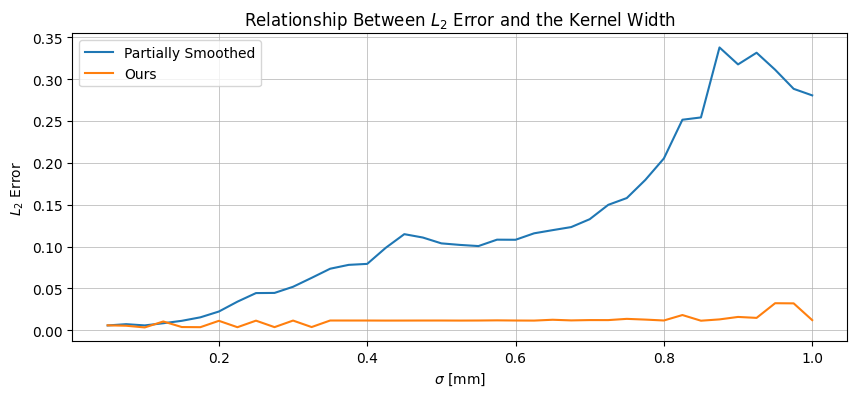

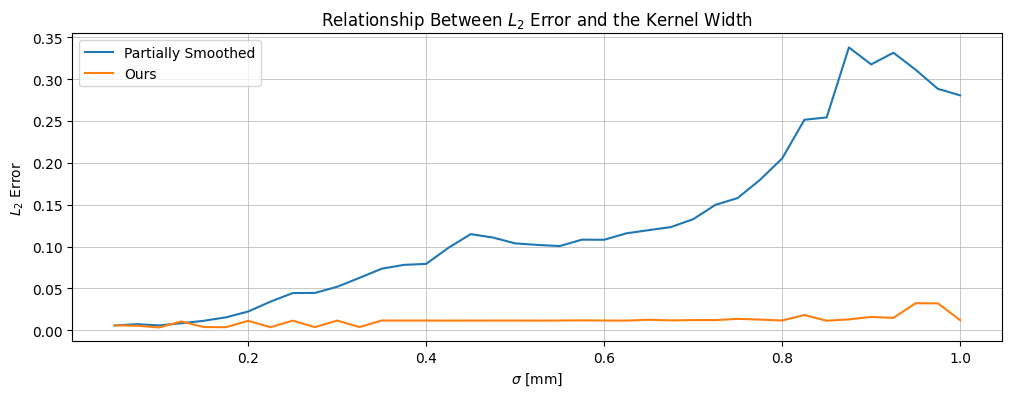

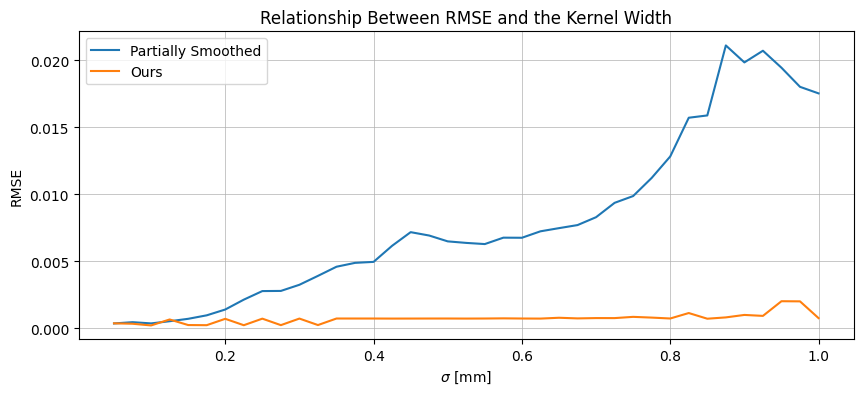

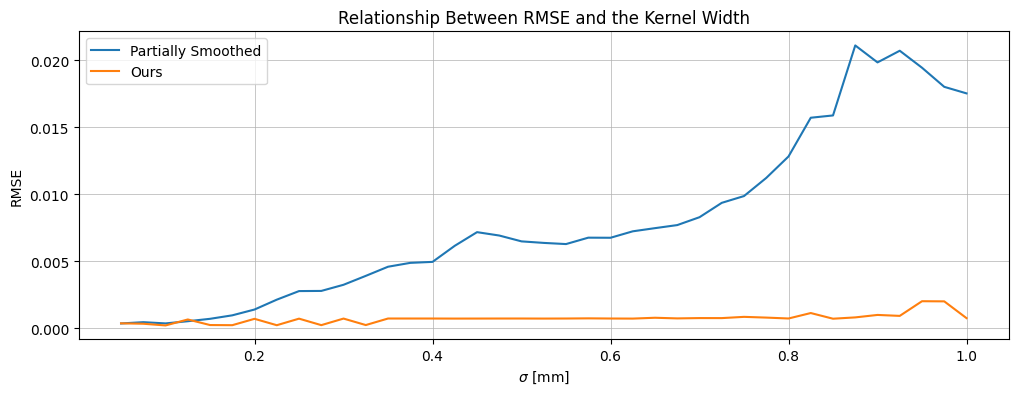

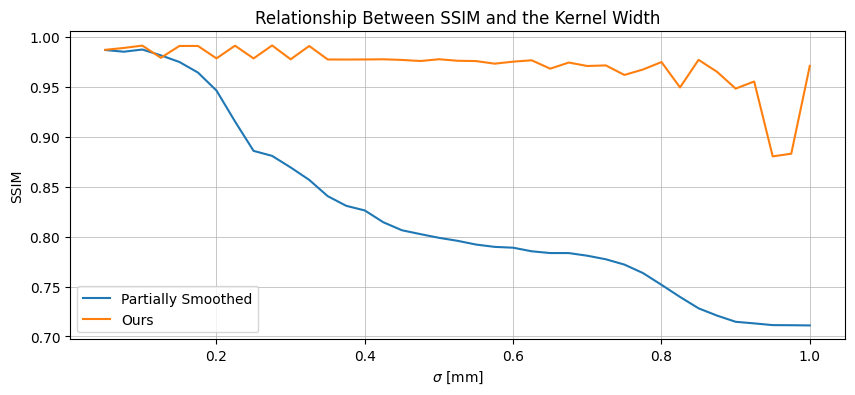

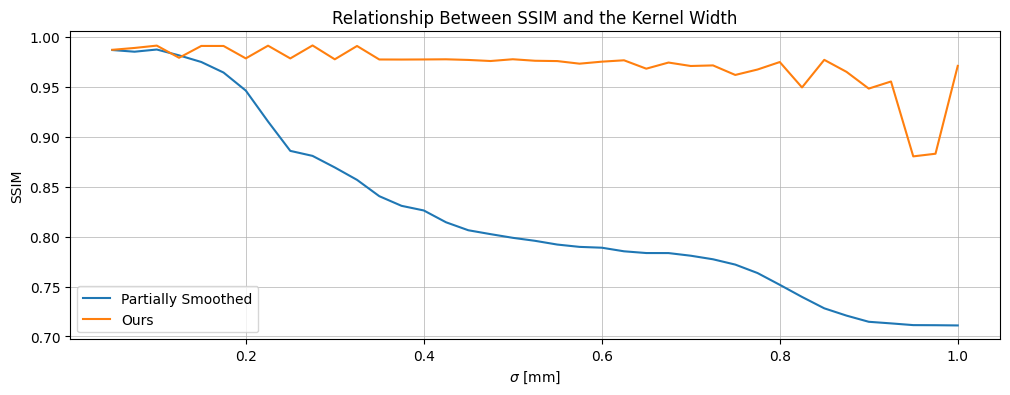

In [8]:
line_plots = []
line_plots.append({"key":"convergence_list","title":"Relationship Between $L_2$ Error and the Kernel Width","ylabel":"$L_2$ Error","file_name":"relationship_l2_error.png"})
line_plots.append({"key":"rmse_list","title":"Relationship Between RMSE and the Kernel Width","ylabel":"RMSE","file_name":"relationship_rmse.png"})
line_plots.append({"key":"ssim_list","title":"Relationship Between SSIM and the Kernel Width","ylabel":"SSIM","file_name":"relationship_ssim.png"})

def make_line_plot(key,title,ylabel,file_name, is_wide):
    if is_wide:
        file_name = "wide_"+file_name
        plt.figure(figsize=(12,4))
    else:
        file_name = "small_"+file_name
        plt.figure(figsize=(10,4))
    baseline_conv = [result[key][-1] for result in baseline_results]
    our_conv = [result[key][-1] for result in our_results]
    sigmas = [result["sigma"] for result in our_results]
    ax = plt.gca()
    ax.grid(True, which='major', linestyle='-', linewidth=0.5)  # Minor grid lines (finer)
    ax.grid(True, which='minor', linestyle='-', linewidth=0.5)  # Minor grid lines (finer)
    ax.set_xlabel("$\\sigma$ [mm]")
    ax.set_ylabel(ylabel)
    plt.plot(sigmas,baseline_conv,label="Partially Smoothed")
    plt.plot(sigmas,our_conv,label="Ours")
    plt.title(title)
    plt.legend()
    #plt.yscale("log")
    plt.savefig(results_folder+file_name, dpi=400, bbox_inches='tight')
    plt.show()
for _plot in line_plots:
    make_line_plot(**_plot, is_wide=False)
    make_line_plot(**_plot, is_wide=True)


In [9]:
idx = torch.arange(len(baseline_results)//4)*5
idx = [0,10,20,30,38]


In [10]:
xbaseline_results = [baseline_results[i] for i in idx]
xour_results = [our_results[i]for i in idx]
xbaseline_results
data_grid = [[]]*4
#result["smooth_irr"] = smooth_irr.cpu().detach()
#result["none_smooth_irr"] = none_smooth_irr.cpu().detach()

data_grid[0] = [result["smooth_irr"] for result in xbaseline_results]
data_grid[1] = [result["smooth_irr"] for result in xour_results]
data_grid[2] = [result["none_smooth_irr"] for result in xbaseline_results]
data_grid[3] = [result["none_smooth_irr"] for result in xour_results]


In [11]:

[f'σ={result["sigma"]} mm' for result in xbaseline_results]

['σ=0.05 mm', 'σ=0.3 mm', 'σ=0.55 mm', 'σ=0.8 mm', 'σ=1.0 mm']

In [12]:
from PIL import Image, ImageDraw, ImageFont
from importlib import reload

from image_grid_maker import image_from_grid
import image_grid_maker
reload(image_grid_maker)
from image_grid_maker import image_from_grid
import image_grid_maker

out_aperture = 8.0
vmin = 0.0
vmax = 0.03

rows_extent = [[-out_aperture,out_aperture,-out_aperture,out_aperture]]*4
rows_vidx = ["x","x","x","x"]
rows_cmap = ["jet"]*4
cbar_titles = ["[W/mm²]"]*4
columns_title = [f'σ={result["sigma"]} mm' for result in baseline_results]
columns_title = [columns_title[i] for i in idx]
rows_title = ["(Partially Smoothed)\nSmoothed Irr.","(Ours)\nSmoothed Irr.","(Partially Smoothed)\nIrr. RC","(Ours)\nIrr. RC"]

data_grid = [data_grid[0],data_grid[2],data_grid[1],data_grid[3]]
rows_title = [rows_title[0],rows_title[2],rows_title[1],rows_title[3]]

rows_vmin = [vmin]*4
rows_vmax = [vmax]*4

kwargs = dict(
        image_grid=data_grid,
        rows_extent=rows_extent,
        rows_vidx=rows_vidx,
        rows_cmap=rows_cmap,
        rows_title=rows_title,
        cbar_titles=cbar_titles,
        columns_title=columns_title,
        rows_vmin=rows_vmin,
        rows_vmax=rows_vmax,
)
out = image_from_grid(
    **kwargs,
    max_num_column=len(columns_title),
    font_size_PIL=40,
    cbar_labelsize=20,
    cbar_title_fontsize=20,
    column_title_ratio=0.3
    )
out = out[0]



# Load an image from the file path
image = Image.open(out)
image.save(results_folder+"comparison_collimated.png")

result,system = run_optimiaztion(sigmas[0],use_desired_irradiance_smoothing=True,return_system=True)



rows vmin: [0.0, 0.0, 0.0, 0.0] rows vmax: [0.03, 0.03, 0.03, 0.03]
_image_from_grid 4 4


In [13]:
#([tensor(0.), tensor(0.), tensor(0.), tensor(0.)],
# [tensor(0.0288), tensor(0.4965), tensor(0.0287), tensor(0.0393)])


C:\Users\marti\AppData\Local\Temp\ipykernel_22656\1628606591.py:19: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:256.)
  tmp = torch.tensor([tmp])[0].reshape(2,-1).T


irr_source torch.Size([512, 512])
desired_irr torch.Size([512, 512]) torch.Size([262144, 2])


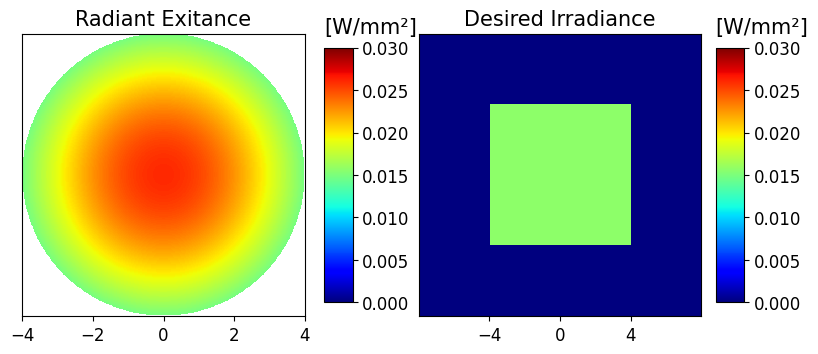

In [14]:
out_aperture = 8.0

import numpy as np
import plotly.graph_objects as go

system.cpu()
source = system.modules_dict["source"]
lens1 = system.modules_dict["lens1"]
detector = system.modules_dict["detector"]

in_aperture = 4.0
num_bins = 512

x = np.linspace(-in_aperture, in_aperture, num_bins)  # Width
y = np.linspace(-in_aperture, in_aperture, num_bins)  # Height
z = torch.zeros((num_bins, num_bins))

tmp = np.meshgrid(x,y)
tmp = torch.tensor([tmp])[0].reshape(2,-1).T

irr_source = source.get_flux(tmp)
irr_source[torch.linalg.norm(tmp,dim=1)>in_aperture]=torch.nan
irr_source = irr_source.reshape(num_bins,num_bins)
print("irr_source",irr_source.shape)

desired_width_square = 4.
def desired_irradiance_func(y):
    out = (torch.abs(y[:,0]) < desired_width_square).float() * (torch.abs(y[:,1]) < desired_width_square).float()
    return out/((desired_width_square*2)**2)
#dit.plotting.quantity2D.plot(irr_source,title="Radiant Exitance [W/mm²]",x_range=[-out_aperture,out_aperture],cmap="hot")

x = np.linspace(-out_aperture, out_aperture, num_bins)  # Width
y = np.linspace(-out_aperture, out_aperture, num_bins)  # Height
z = torch.zeros((num_bins, num_bins))

tmp = np.meshgrid(x,y)
tmp = torch.tensor([tmp])[0].reshape(2,-1).T

desired_irr = desired_irradiance_func(tmp.reshape(-1,2)).reshape(num_bins,num_bins)
print("desired_irr",desired_irr.shape,tmp.shape)

#vmax = torch.max(irr_source).item()

import matplotlib.pyplot as plt

# Assume you already have:
# - irrs: list of 2D arrays (irradiance maps)
# - rows_extent: list of [xmin, xmax, ymin, ymax] per image
# - sigmas: list of sigma values used for smoothing

cbar_labelsize=12
cbar_title_fontsize=15
# Grid dimensions
rows_extent = [[-in_aperture, in_aperture, -in_aperture, in_aperture]] +[[-out_aperture, out_aperture, -out_aperture, out_aperture]]
irrs = [irr_source,desired_irr]
irrs = [irr.cpu() for irr in irrs]

num_rows = 1
num_cols = len(irrs)

fig, axes = plt.subplots(num_rows, num_cols, figsize=(4 * num_cols, 4), constrained_layout=True)

# Titles for each column
columns_title = ["Radiant Exitance"] + [f"Desired Irradiance" for sigma in sigmas]
cmaps = ["jet","jet"]
cbar_title = "[W/mm²]"

for k in range(num_cols):
    ax = axes[k]
    img = irrs[k]
    cmap = cmaps[k]
    im = ax.imshow(img, extent=rows_extent[k],origin='lower', cmap=cmap,interpolation="nearest",vmin=vmin,vmax=vmax)
    ax.set_title(columns_title[k],fontsize=cbar_title_fontsize)
    if k != 0:
        ax.set_xticks([-4,0,4])
    ax.set_yticks([])
    ax.tick_params(labelsize=cbar_labelsize)

    cbar = plt.colorbar(im,ax=ax,shrink=0.65,aspect=9)  # Add a colorbar for reference
    cbar.ax.tick_params(labelsize=cbar_labelsize)
    cbar.ax.set_title(cbar_title, fontsize=cbar_title_fontsize, pad=10,loc="left")  # Set label above
    offset_text = cbar.ax.yaxis.offsetText
    offset_text.set_size(cbar_labelsize)  # Set the font size
    offset_text.set_ha('left')  # Align the text to the left

#plt.suptitle("Irradiance Maps from Ray Counting and Smoothing", fontsize=16)
plt.savefig(results_folder+"radiant_exitance_desired_irr.png", dpi=400, bbox_inches='tight')

plt.show()


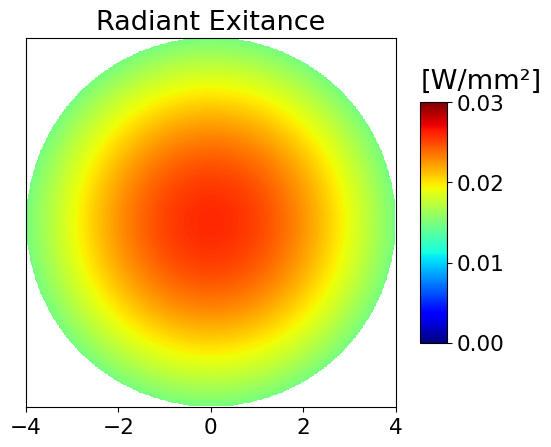

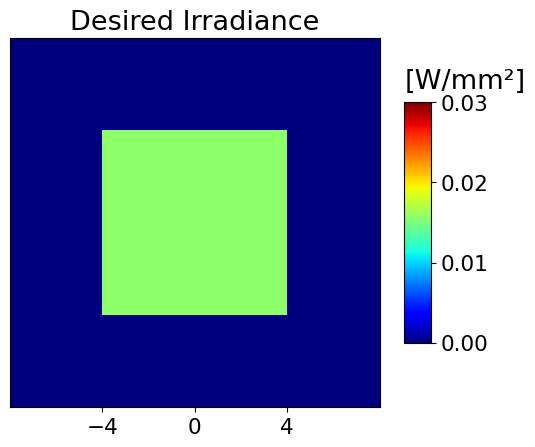

In [15]:
font_multi = 1.3
for k in range(num_cols):
    ax = plt.gca()
    img = irrs[k]
    cmap = "jet"
    im = ax.imshow(img, extent=rows_extent[k],origin='lower', cmap=cmap,interpolation="nearest",vmin=vmin,vmax=vmax)
    ax.set_title(columns_title[k],fontsize=cbar_title_fontsize*font_multi)
    if k != 0:
        ax.set_xticks([-4,0,4])
    ax.set_yticks([])
    ax.tick_params(labelsize=cbar_labelsize*font_multi)

    cbar = plt.colorbar(im,ax=ax,shrink=0.65,aspect=9)  # Add a colorbar for reference
    cbar.ax.tick_params(labelsize=cbar_labelsize*font_multi)
    cbar.ax.set_title(cbar_title, fontsize=cbar_title_fontsize*font_multi, pad=10,loc="left")  # Set label above
    offset_text = cbar.ax.yaxis.offsetText
    offset_text.set_size(cbar_labelsize*font_multi)  # Set the font size
    offset_text.set_ha('left')  # Align the text to the left

    plt.savefig(results_folder+f"radiant_exitance_desired_irr_sep{k}.png", dpi=400, bbox_inches='tight')
    plt.show()


In [16]:
xr,_ = source.sample(15)
sequence = ["source","lens1","detector"]

O,D,wave_len,_,RayPaths = system(xr,sequence)

if not RayPaths is None:
    if isinstance(RayPaths,dict):
        rays = RayPaths["ray_paths"]

show_grid=True
xlabel="x [mm]"
ylabel="y [mm]"
zlabel="z [mm]"
xticks=None
yticks=None
zticks=None
axislabel_font_size=10
tick_font_size=10
ray_color="#9673A6"
ray_linewidth=3.

data = []
resolution = 32
data += dit.plotting.system3D._plot_surface_recursively(lens1,"",resolution)
data += dit.plotting.system3D._plot_surface_recursively(source,"",resolution)

data += dit.plotting.system3D.ray_paths(rays,ray_color,ray_linewidth)
layout = dit.plotting.system3D.get_optical_system_layout(False,xlabel,ylabel,zlabel,xticks,yticks,zticks,axislabel_font_size,tick_font_size)


import plotly.graph_objects as go
none_smooth_irr = result["none_smooth_irr"]

num_bins = none_smooth_irr.shape[0]

out_aperture = 8.0

x = np.linspace(-out_aperture, out_aperture, num_bins)  # Width
y = np.linspace(-out_aperture, out_aperture, num_bins)  # Height
z = torch.ones((num_bins, num_bins))*detector.get_transformation_matrix()[2,3]        # Flat surface
z = z.detach()
gosurface2 = go.Surface(
        x=x,
        y=y,
        z=z,
        surfacecolor=none_smooth_irr,
        cmin=vmin,
        cmax=vmax,
        colorbar=dict(
        title=dict(text='[W/mm²]', font=dict(size=16)),  # Increase title font size
        tickfont=dict(size=14)  # Increase tick font size
        ),
        colorscale="jet",
        showscale=True,
        showlegend=False
)

data += [gosurface2]
fig = go.Figure(data=data,layout=layout)
fig.write_html(results_folder+"collimated2.html")
#fig.show()


c:\Users\marti\anaconda3\envs\working\Lib\site-packages\torch\functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\TensorShape.cpp:4383.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


In [17]:
def create_optical_system_from_light_source(source):
    in_aperture_lens = 5.0

    
    out_aperture = 8.0
    
    
    lens_mat = dit.materials["NBK7"]
    env_mat = dit.materials["NONE"]

    lens1_thickness = 2.
    lens1_surf1 = dit.Bspline(in_aperture_lens,[4,4],[11,11])#dit.Legendre(in_aperture_lens,20)#
    lens1_surf2 = dit.Plane()

    det_surf = dit.Plane()

    lens1_transform = dit.transforms.Distance(5.0,parent_transform=source)
    lens1_transform.distance.requires_grad = False

    lens1 = dit.Lens(lens1_transform,lens1_thickness,lens1_surf1,lens1_surf2,lens_mat,in_aperture_lens,is_square=False)


    det_transform = dit.transforms.Distance(10.,parent_transform=lens1)
    det_transform.distance.requires_grad = False
    detector = dit.Detector(det_transform,det_surf,out_aperture)

    system = dit.SequentialOpticalSystem({"source":source,"lens1":lens1,"detector":detector},env_mat)
    return system

def create_collimated_system():
    light_transform = dit.transforms.Identity()
    in_aperture = 4.0
    source_wl = 0.589
    source_gaussian_constant = 0.035
    source = dit.source.CollimatedMonochromatic1D(light_transform,in_aperture,source_wl)
    system = create_optical_system_from_light_source(source)
    return system



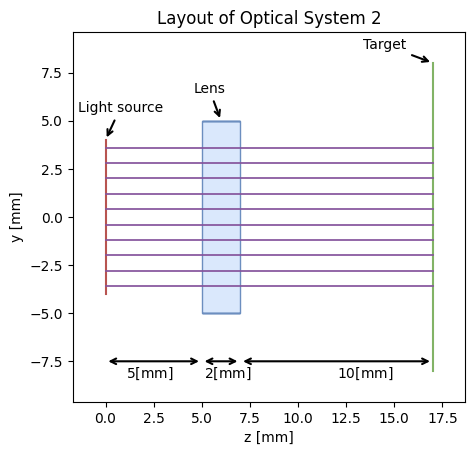

In [18]:
system_collimated = create_collimated_system()

xr,_ = system_collimated.modules_dict["source"].sample([10],"midpoint")
sequence = ["source","lens1","detector"]
offset_arrows = -7.5

O,D,wave_len,_,RayPaths = system_collimated(xr,sequence)
plt.title("Layout of Optical System 2")
dit.plotting.system2D.plot(system_collimated,RayPaths,show=False)
dit.plotting.system2D.annotated_arrow([0,offset_arrows],[5,offset_arrows],(-20,-12),"$5$[mm]","<->")
dit.plotting.system2D.annotated_arrow([5,offset_arrows],[5+2,offset_arrows],(-12,-12),"$2$[mm]","<->")
dit.plotting.system2D.annotated_arrow([5+2,offset_arrows],[5+2+10,offset_arrows],(0,-12),"$10$[mm]","<->")
dit.plotting.system2D.annotate_position([0,4],(-20,20),"Light source")
dit.plotting.system2D.annotate_position([5+1,5],(-20,20),"Lens")
dit.plotting.system2D.annotate_position([5+2+10,8],(-50,10),"Target")
#plt.margins(x=0.2,y=0.2)